# Create Modelling Data for GAM
## Setup 
### Import Python Packages 

In [2]:
# External packages
import pandas as pd
import numpy as np
import sys
from pprint import pprint

# import random
# import os

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Internal packages
sys.path.append("../")
sys.path.append("../../")
from src import utils

pd.set_option("display.max_columns", 100)

### Set Variables

In [3]:
# Fontsize for visualisation
tick_fontsize = 14
label_fontsize = 18
title_fontsize = 22

# Define the exposure and death counts (both actual and expected)
exposure = "Policies_Exposed"
act_death = "Death_Count"
exp_death_mi = "ExpDth_VBT2015wMI_Cnt"

# Define a dict that maps the counts to rates
count_to_rate_dict = {
    act_death: "act_death_rate", 
    exp_death_mi: "exp_death_rate_mi"
} 

# Define holdout and random fold column names 
holdout = "holdout"
random_fold = "random_fold"
data_version = "_ml_cy_split"

# Data
data_file = f"../export/ILEC_2012_19_aggregated_20260123.parquet"

## Create Modelling Data
### Import Data

In [4]:
df_data = pd.read_parquet(data_file)
df_data

,Observation_Year,Sex,Smoker_Status,Issue_Age,Duration,Face_Amount_Band,Issue_Year,Attained_Age,Death_Count,Policies_Exposed,ExpDth_VBT2015wMI_Cnt,is_test,is_validation
0,2012,M,NS,34,17,"05: 100,000 - 249,999",1996,50,0.0,1546.786003,2.355224,True,False
1,2012,M,NS,34,17,"06: 250,000 - 499,999",1995,50,0.0,792.154739,1.203345,True,False
2,2012,M,NS,34,17,"06: 250,000 - 499,999",1996,50,2.0,1031.760315,1.567217,False,False
3,2012,M,NS,34,17,"07: 500,000 - 999,999",1995,50,0.0,327.323694,0.497118,False,False
4,2012,M,NS,34,17,"07: 500,000 - 999,999",1996,50,0.0,458.157228,0.694401,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
612760,2019,M,S,76,2,"01: 0 - 9,999",2018,77,0.0,0.882192,0.018247,False,False
612761,2019,M,S,76,2,"02: 10,000 - 24,999",2017,77,0.0,0.213699,0.004420,False,False
612762,2019,M,S,78,2,"02: 10,000 - 24,999",2017,79,0.0,0.512329,0.012250,False,False
612763,2019,M,S,80,4,"02: 10,000 - 24,999",2015,83,0.0,0.082192,0.004593,False,False


### Map categorical levels to integer values

In [5]:
##################################################################
##################################################################

# Define a list of categorical variables
cat_feat = ["Sex", "Smoker_Status"]

# Define the categorical banding output
output_cat_map = f"../export/SOA Categorical Mapping{data_version}.xlsx"

##################################################################
##################################################################

# Save categorical mappings
with pd.ExcelWriter(output_cat_map, engine="openpyxl") as writer:
    for var in cat_feat:
        # Create a dataframe that contains the unique values and their associated integer values
        df_ = pd.DataFrame(df_data[var].unique(), columns=["Categorical_Level"])
        df_.sort_values("Categorical_Level", inplace=True)
        df_["Integer_Value"] = list(range(len(df_)))

        # Save the mapping table
        df_.to_excel(writer, sheet_name=var, index=False)

        # Map the categorical variable into integer values
        df_data[var + "_cat_level"] = df_data[var].map(
            df_.set_index("Categorical_Level").to_dict()["Integer_Value"]
        )

df_data

,Observation_Year,Sex,Smoker_Status,Issue_Age,Duration,Face_Amount_Band,Issue_Year,Attained_Age,Death_Count,Policies_Exposed,ExpDth_VBT2015wMI_Cnt,is_test,is_validation,Sex_cat_level,Smoker_Status_cat_level
0,2012,M,NS,34,17,"05: 100,000 - 249,999",1996,50,0.0,1546.786003,2.355224,True,False,1,0
1,2012,M,NS,34,17,"06: 250,000 - 499,999",1995,50,0.0,792.154739,1.203345,True,False,1,0
2,2012,M,NS,34,17,"06: 250,000 - 499,999",1996,50,2.0,1031.760315,1.567217,False,False,1,0
3,2012,M,NS,34,17,"07: 500,000 - 999,999",1995,50,0.0,327.323694,0.497118,False,False,1,0
4,2012,M,NS,34,17,"07: 500,000 - 999,999",1996,50,0.0,458.157228,0.694401,False,False,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612760,2019,M,S,76,2,"01: 0 - 9,999",2018,77,0.0,0.882192,0.018247,False,False,1,1
612761,2019,M,S,76,2,"02: 10,000 - 24,999",2017,77,0.0,0.213699,0.004420,False,False,1,1
612762,2019,M,S,78,2,"02: 10,000 - 24,999",2017,79,0.0,0.512329,0.012250,False,False,1,1
612763,2019,M,S,80,4,"02: 10,000 - 24,999",2015,83,0.0,0.082192,0.004593,False,False,1,1


In [6]:
####################################################################
####################################################################

var = "Sex"
format_dict = {exposure: "{:,.0f}"}
bar_dict = {exposure: "grey"}
caption = f"{var} Distribution"

####################################################################
####################################################################

# Check the distribution of one categorical variable and its integer values
df_gb = df_data.groupby([var, var + "_cat_level"], dropna=False, observed=True)[
    [exposure]
].sum()

# Display result
df_gb.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,,Policies_Exposed
Sex,Sex_cat_level,
F,0,"70,612,584"
M,1,"89,565,763"


### Convert Face_Amount_Band into ordinal variable

In [7]:
df_data["Face_Amount_Band_ordinal"] = df_data["Face_Amount_Band"].str[:2].astype(int)
df_data

,Observation_Year,Sex,Smoker_Status,Issue_Age,Duration,Face_Amount_Band,Issue_Year,Attained_Age,Death_Count,Policies_Exposed,ExpDth_VBT2015wMI_Cnt,is_test,is_validation,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal
0,2012,M,NS,34,17,"05: 100,000 - 249,999",1996,50,0.0,1546.786003,2.355224,True,False,1,0,5
1,2012,M,NS,34,17,"06: 250,000 - 499,999",1995,50,0.0,792.154739,1.203345,True,False,1,0,6
2,2012,M,NS,34,17,"06: 250,000 - 499,999",1996,50,2.0,1031.760315,1.567217,False,False,1,0,6
3,2012,M,NS,34,17,"07: 500,000 - 999,999",1995,50,0.0,327.323694,0.497118,False,False,1,0,7
4,2012,M,NS,34,17,"07: 500,000 - 999,999",1996,50,0.0,458.157228,0.694401,False,False,1,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612760,2019,M,S,76,2,"01: 0 - 9,999",2018,77,0.0,0.882192,0.018247,False,False,1,1,1
612761,2019,M,S,76,2,"02: 10,000 - 24,999",2017,77,0.0,0.213699,0.004420,False,False,1,1,2
612762,2019,M,S,78,2,"02: 10,000 - 24,999",2017,79,0.0,0.512329,0.012250,False,False,1,1,2
612763,2019,M,S,80,4,"02: 10,000 - 24,999",2015,83,0.0,0.082192,0.004593,False,False,1,1,2


In [8]:
####################################################################
####################################################################

var = "Face_Amount_Band"
format_dict = {exposure: "{:,.0f}"}
bar_dict = {exposure: "grey"}
caption = f"{var} Distribution"

####################################################################
####################################################################

# Check its distribution
df_gb = df_data.groupby([var, var + "_ordinal"], dropna=False, observed=True)[[exposure]].sum()

# Display result
df_gb.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,,Policies_Exposed
Face_Amount_Band,Face_Amount_Band_ordinal,
"01: 0 - 9,999",1,"164,327"
"02: 10,000 - 24,999",2,"922,817"
"03: 25,000 - 49,999",3,"2,418,007"
"04: 50,000 - 99,999",4,"7,231,262"
"05: 100,000 - 249,999",5,"45,113,818"
"06: 250,000 - 499,999",6,"47,547,702"
"07: 500,000 - 999,999",7,"34,614,339"
"08: 1,000,000 - 2,499,999",8,"20,148,104"
"09: 2,500,000 - 4,999,999",9,"1,445,132"


### Cap Duration 
Duration above 20 behaves strangely - could be due to anti-selection, hence the capping

In [9]:
df_data["Duration"] = np.where(df_data["Duration"] <= 20, df_data["Duration"], 20)

In [10]:
####################################################################
####################################################################

var = "Duration"
format_dict = {exposure: "{:,.0f}"}
bar_dict = {exposure: "grey"}
caption = f"{var} Distribution"

####################################################################
####################################################################

# Check its distribution
df_gb = df_data.groupby([var], dropna=False)[[exposure]].sum()

# Display result
df_gb.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,Policies_Exposed
Duration,
1,"12,282,543"
2,"11,289,493"
3,"10,728,998"
4,"10,445,317"
5,"10,193,880"
6,"9,911,178"
7,"9,708,034"
8,"9,582,746"
9,"9,521,811"


### Define Training/Holdout Sets and Random Folds

In [12]:
# Set the last two observation years as the holdout
df_data[holdout] = np.where(df_data["Observation_Year"].isin([2018, 2019]), 1, 0)
df_data

,Observation_Year,Sex,Smoker_Status,Issue_Age,Duration,Face_Amount_Band,Issue_Year,Attained_Age,Death_Count,Policies_Exposed,ExpDth_VBT2015wMI_Cnt,is_test,is_validation,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout
0,2012,M,NS,34,17,"05: 100,000 - 249,999",1996,50,0.0,1546.786003,2.355224,True,False,1,0,5,0
1,2012,M,NS,34,17,"06: 250,000 - 499,999",1995,50,0.0,792.154739,1.203345,True,False,1,0,6,0
2,2012,M,NS,34,17,"06: 250,000 - 499,999",1996,50,2.0,1031.760315,1.567217,False,False,1,0,6,0
3,2012,M,NS,34,17,"07: 500,000 - 999,999",1995,50,0.0,327.323694,0.497118,False,False,1,0,7,0
4,2012,M,NS,34,17,"07: 500,000 - 999,999",1996,50,0.0,458.157228,0.694401,False,False,1,0,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612760,2019,M,S,76,2,"01: 0 - 9,999",2018,77,0.0,0.882192,0.018247,False,False,1,1,1,1
612761,2019,M,S,76,2,"02: 10,000 - 24,999",2017,77,0.0,0.213699,0.004420,False,False,1,1,2,1
612762,2019,M,S,78,2,"02: 10,000 - 24,999",2017,79,0.0,0.512329,0.012250,False,False,1,1,2,1
612763,2019,M,S,80,4,"02: 10,000 - 24,999",2015,83,0.0,0.082192,0.004593,False,False,1,1,2,1


In [14]:
####################################################################
####################################################################

var = ["Observation_Year", holdout]
format_dict = {exposure: "{:,.0f}"}
bar_dict = {exposure: "grey"}
caption = f"{var} Distribution"

####################################################################
####################################################################

# Check its distribution
df_gb = df_data.groupby(var, dropna=False)[[exposure]].sum()

# Display result
df_gb.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,,Policies_Exposed
Observation_Year,holdout,
2012,0,"16,718,125"
2013,0,"19,567,515"
2014,0,"19,905,093"
2015,0,"20,517,497"
2016,0,"20,698,928"
2017,0,"20,694,185"
2018,1,"21,133,056"
2019,1,"20,943,949"


In [15]:
#####################################################################################
#####################################################################################

seed = 2026
num_fold = 5

#####################################################################################
#####################################################################################

# Define a column for random folds for cross validations
np.random.seed(seed)
df_data[random_fold] = np.random.randint(1, num_fold + 1, len(df_data))
df_data[random_fold] = np.where(
    df_data[holdout] == 0, df_data[random_fold], num_fold + 1
)
df_data

,Observation_Year,Sex,Smoker_Status,Issue_Age,Duration,Face_Amount_Band,Issue_Year,Attained_Age,Death_Count,Policies_Exposed,ExpDth_VBT2015wMI_Cnt,is_test,is_validation,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout,random_fold
0,2012,M,NS,34,17,"05: 100,000 - 249,999",1996,50,0.0,1546.786003,2.355224,True,False,1,0,5,0,2
1,2012,M,NS,34,17,"06: 250,000 - 499,999",1995,50,0.0,792.154739,1.203345,True,False,1,0,6,0,3
2,2012,M,NS,34,17,"06: 250,000 - 499,999",1996,50,2.0,1031.760315,1.567217,False,False,1,0,6,0,1
3,2012,M,NS,34,17,"07: 500,000 - 999,999",1995,50,0.0,327.323694,0.497118,False,False,1,0,7,0,5
4,2012,M,NS,34,17,"07: 500,000 - 999,999",1996,50,0.0,458.157228,0.694401,False,False,1,0,7,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612760,2019,M,S,76,2,"01: 0 - 9,999",2018,77,0.0,0.882192,0.018247,False,False,1,1,1,1,6
612761,2019,M,S,76,2,"02: 10,000 - 24,999",2017,77,0.0,0.213699,0.004420,False,False,1,1,2,1,6
612762,2019,M,S,78,2,"02: 10,000 - 24,999",2017,79,0.0,0.512329,0.012250,False,False,1,1,2,1,6
612763,2019,M,S,80,4,"02: 10,000 - 24,999",2015,83,0.0,0.082192,0.004593,False,False,1,1,2,1,6


In [16]:
####################################################################
####################################################################

var = [random_fold, holdout]

format_dict = {
    exposure: "{:,.0f}",
    **{k: "{:,.0f}" for k, _ in count_to_rate_dict.items()},
    **{v: "{:,.4%}" for _, v in count_to_rate_dict.items()},
}
bar_dict = {
    exposure: "grey",
    **{k: "grey" for k, _ in count_to_rate_dict.items()},
    **{v: "blue" for _, v in count_to_rate_dict.items()},
}
caption = f"{var} Distribution"

####################################################################
####################################################################

# Check its distribution and the actual and expected death rates
df_gb = df_data.groupby(var, dropna=False)[
    [exposure, act_death, exp_death_mi]
].sum()

for k, v in count_to_rate_dict.items():
    df_gb[v] = df_gb[k] / df_gb[exposure]

# Display result
df_gb.style.pipe(
    lambda x: utils.make_pretty_pivot(x, format_dict, caption, bar_dict=bar_dict)
)

,,Policies_Exposed,Death_Count,ExpDth_VBT2015wMI_Cnt,act_death_rate,exp_death_rate_mi
random_fold,holdout,,,,,
1,0,"23,486,084","40,263","38,449",0.1714%,0.1637%
2,0,"23,922,748","40,130","38,719",0.1677%,0.1618%
3,0,"23,478,633","40,350","38,892",0.1719%,0.1656%
4,0,"23,411,918","39,746","38,708",0.1698%,0.1653%
5,0,"23,801,959","40,151","39,108",0.1687%,0.1643%
6,1,"42,077,005","72,762","77,982",0.1729%,0.1853%


### Create normalised target variables
PyGAM doesn't have an offset functionality, hence the need to create actual and expected death rates. 

In [17]:
for k, v in count_to_rate_dict.items(): 
    df_data[v] = df_data[k] / df_data[exposure]
df_data

,Observation_Year,Sex,Smoker_Status,Issue_Age,Duration,Face_Amount_Band,Issue_Year,Attained_Age,Death_Count,Policies_Exposed,ExpDth_VBT2015wMI_Cnt,is_test,is_validation,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout,random_fold,act_death_rate,exp_death_rate_mi
0,2012,M,NS,34,17,"05: 100,000 - 249,999",1996,50,0.0,1546.786003,2.355224,True,False,1,0,5,0,2,0.000000,0.001523
1,2012,M,NS,34,17,"06: 250,000 - 499,999",1995,50,0.0,792.154739,1.203345,True,False,1,0,6,0,3,0.000000,0.001519
2,2012,M,NS,34,17,"06: 250,000 - 499,999",1996,50,2.0,1031.760315,1.567217,False,False,1,0,6,0,1,0.001938,0.001519
3,2012,M,NS,34,17,"07: 500,000 - 999,999",1995,50,0.0,327.323694,0.497118,False,False,1,0,7,0,5,0.000000,0.001519
4,2012,M,NS,34,17,"07: 500,000 - 999,999",1996,50,0.0,458.157228,0.694401,False,False,1,0,7,0,5,0.000000,0.001516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612760,2019,M,S,76,2,"01: 0 - 9,999",2018,77,0.0,0.882192,0.018247,False,False,1,1,1,1,6,0.000000,0.020683
612761,2019,M,S,76,2,"02: 10,000 - 24,999",2017,77,0.0,0.213699,0.004420,False,False,1,1,2,1,6,0.000000,0.020683
612762,2019,M,S,78,2,"02: 10,000 - 24,999",2017,79,0.0,0.512329,0.012250,False,False,1,1,2,1,6,0.000000,0.023910
612763,2019,M,S,80,4,"02: 10,000 - 24,999",2015,83,0.0,0.082192,0.004593,False,False,1,1,2,1,6,0.000000,0.055880


### Set Unique ID

In [18]:
df_data.index.name = "unique_id"
df_data

,Observation_Year,Sex,Smoker_Status,Issue_Age,Duration,Face_Amount_Band,Issue_Year,Attained_Age,Death_Count,Policies_Exposed,ExpDth_VBT2015wMI_Cnt,is_test,is_validation,Sex_cat_level,Smoker_Status_cat_level,Face_Amount_Band_ordinal,holdout,random_fold,act_death_rate,exp_death_rate_mi
unique_id,,,,,,,,,,,,,,,,,,,,
0,2012,M,NS,34,17,"05: 100,000 - 249,999",1996,50,0.0,1546.786003,2.355224,True,False,1,0,5,0,2,0.000000,0.001523
1,2012,M,NS,34,17,"06: 250,000 - 499,999",1995,50,0.0,792.154739,1.203345,True,False,1,0,6,0,3,0.000000,0.001519
2,2012,M,NS,34,17,"06: 250,000 - 499,999",1996,50,2.0,1031.760315,1.567217,False,False,1,0,6,0,1,0.001938,0.001519
3,2012,M,NS,34,17,"07: 500,000 - 999,999",1995,50,0.0,327.323694,0.497118,False,False,1,0,7,0,5,0.000000,0.001519
4,2012,M,NS,34,17,"07: 500,000 - 999,999",1996,50,0.0,458.157228,0.694401,False,False,1,0,7,0,5,0.000000,0.001516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612760,2019,M,S,76,2,"01: 0 - 9,999",2018,77,0.0,0.882192,0.018247,False,False,1,1,1,1,6,0.000000,0.020683
612761,2019,M,S,76,2,"02: 10,000 - 24,999",2017,77,0.0,0.213699,0.004420,False,False,1,1,2,1,6,0.000000,0.020683
612762,2019,M,S,78,2,"02: 10,000 - 24,999",2017,79,0.0,0.512329,0.012250,False,False,1,1,2,1,6,0.000000,0.023910


### Correlation Matrix

[Text(0.5, 0, 'act_death_rate'),
 Text(1.5, 0, 'exp_death_rate_mi'),
 Text(2.5, 0, 'Observation_Year'),
 Text(3.5, 0, 'Duration'),
 Text(4.5, 0, 'Attained_Age'),
 Text(5.5, 0, 'Issue_Age'),
 Text(6.5, 0, 'Face_Amount_Band_ordinal'),
 Text(7.5, 0, 'Issue_Year'),
 Text(8.5, 0, 'Sex_cat_level'),
 Text(9.5, 0, 'Smoker_Status_cat_level')]

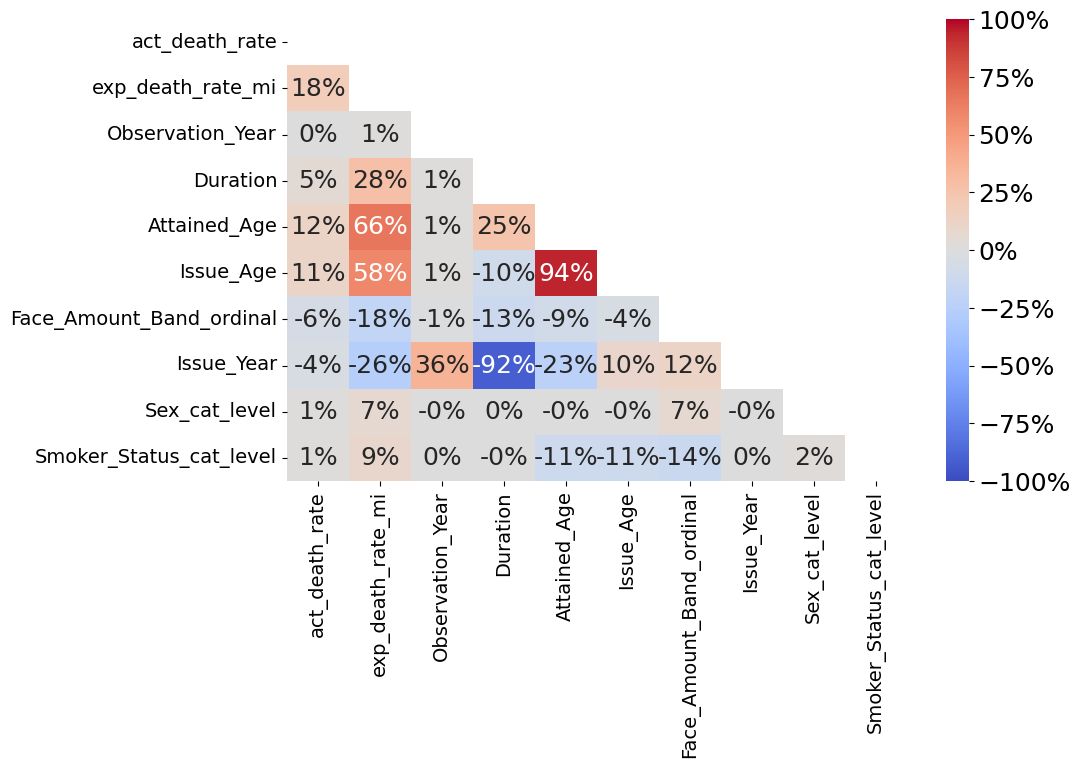

In [19]:
##########################################################################
##########################################################################

# Define a list of column names in-scope for correlation analysis
col_for_corr_list = [
    *[v for _, v in count_to_rate_dict.items()],
    "Observation_Year",
    "Duration",
    "Attained_Age",
    "Issue_Age",
    "Face_Amount_Band_ordinal",
    "Issue_Year",
    *[x + "_cat_level" for x in cat_feat],
]

##########################################################################
##########################################################################

corr_mat = round(df_data[col_for_corr_list].corr(), 2)

# Fill diagonal and upper half with NaNs
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corr_mat[mask] = np.nan

fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.heatmap(
    corr_mat,
    annot=True,
    annot_kws={"size": label_fontsize},
    fmt=".0%",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=label_fontsize)
colorbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

ax.set_facecolor("white")
ax.set_yticklabels(df_data[col_for_corr_list].columns, fontsize=tick_fontsize)
ax.set_xticklabels(df_data[col_for_corr_list].columns, fontsize=tick_fontsize)

## Export files

In [20]:
###########################################################################
###########################################################################

model_data_output = f"../export/Modelling_data (Filtered and Grouped by Selected Features){data_version}.parquet"


###########################################################################
###########################################################################

df_data.to_parquet(
    f"{model_data_output}",
    engine="pyarrow",
    compression="gzip",
)